In [1]:
!pip install torch

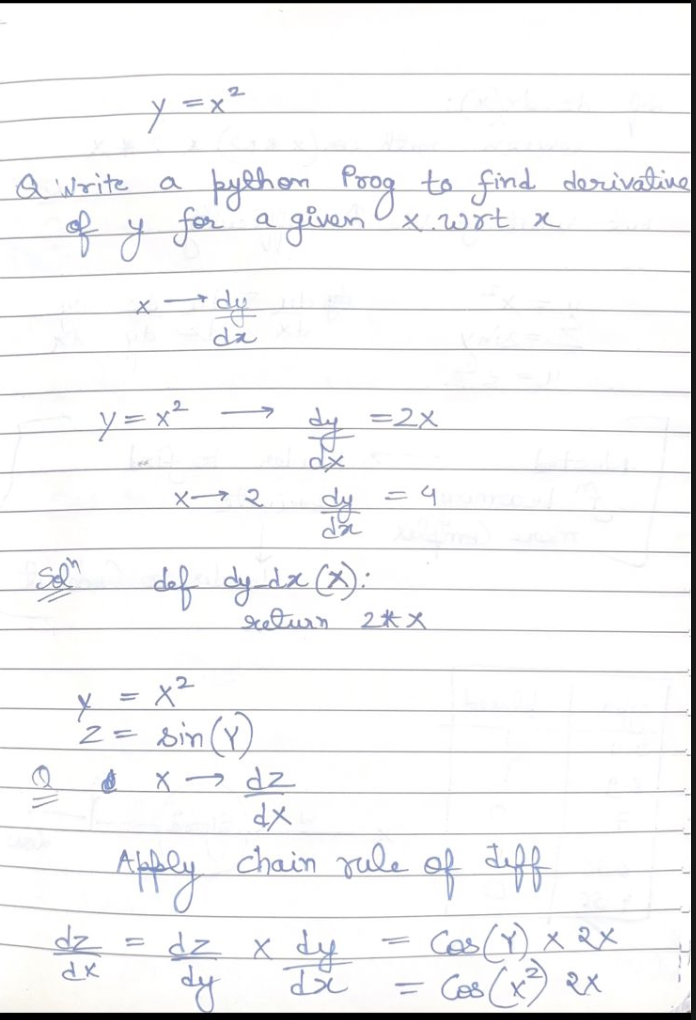

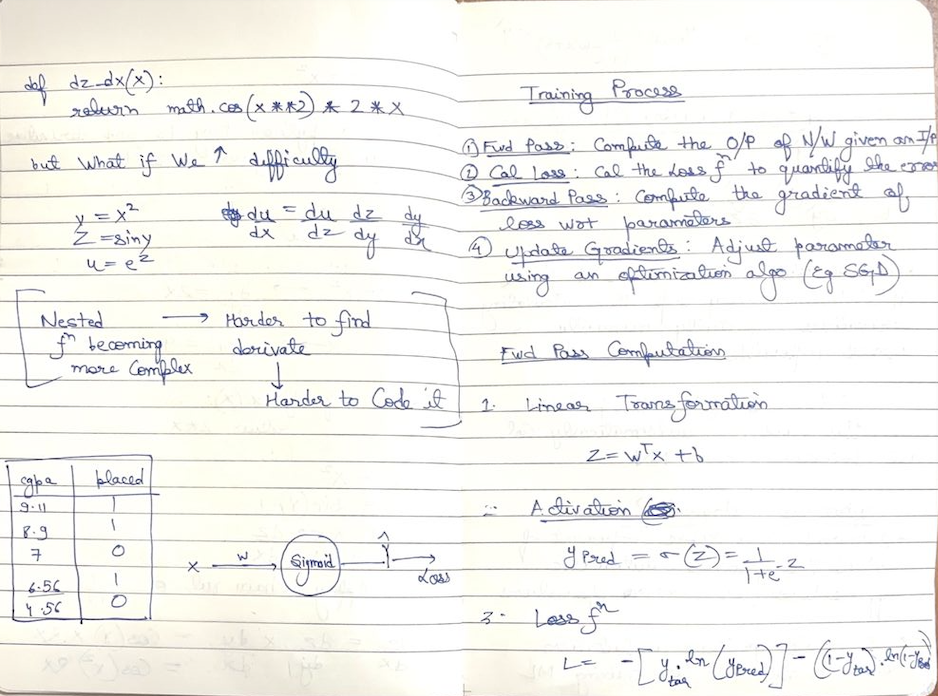

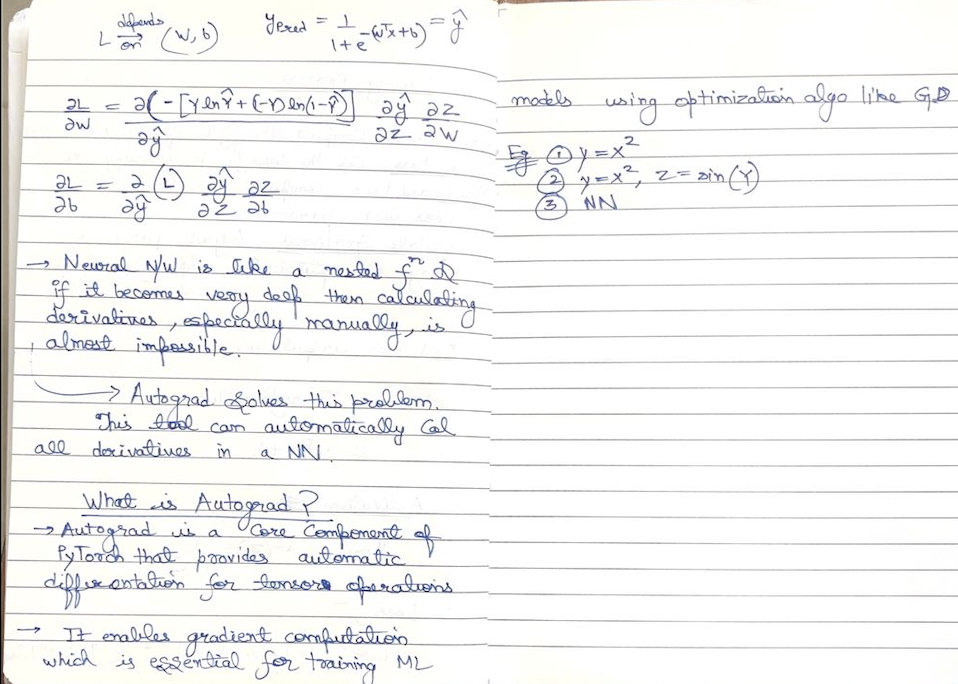

In [3]:
import torch
x=torch.tensor(3.0,requires_grad=True) ## By default it is false

## PyTorch automatically understands that we want to cal derivative of a tensor
## Whenever you need to find gradient of any tensor, you need to set requires_grad=True while creating that tensor

In [4]:
y=x**2

In [5]:
x

## whenever requires_grad=True pytorch internally creates a computation graph

tensor(3., requires_grad=True)

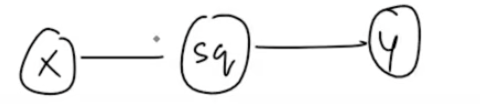

Computation Graph by PyTorch

In [6]:
y

tensor(9., grad_fn=<PowBackward0>)

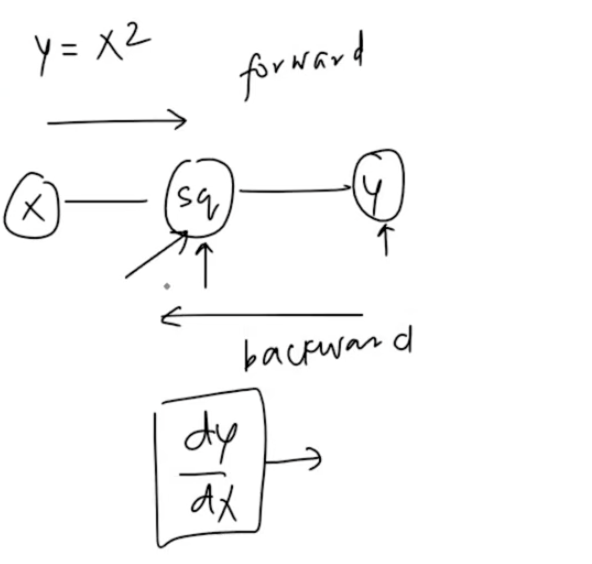

when we go in backward dirn pytorch cal dy/dx for that pytorch needs to know what kind of opn was performed on x to get y



In [7]:
y.backward()

In [8]:
x.grad ##grad is attribute

tensor(6.)

In [11]:
## steps:
import math
x=torch.tensor(12.0,requires_grad=True)
y=torch.cos(x)
y.backward() ## all gardients get calculated in backward direction
x.grad

tensor(0.5366)

In [12]:
import math

def dz_dx(X):
  return 2*X*math.cos(X**2)

dz_dx(3.0)

-5.466781571308061

In [19]:
x=torch.tensor(3.,requires_grad=True)
y=x**2
z=torch.sin(y)
print(x)
print(y)
print(z)

tensor(3., requires_grad=True)
tensor(9., grad_fn=<PowBackward0>)
tensor(0.4121, grad_fn=<SinBackward0>)


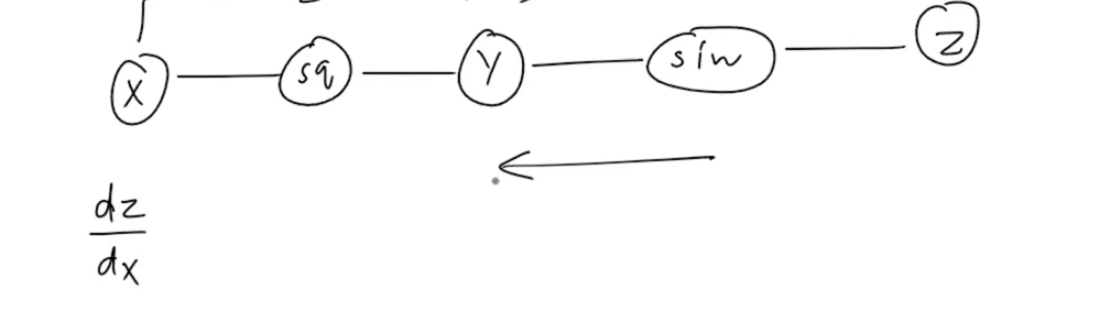

In [20]:
z.backward()
x.grad

tensor(-5.4668)

In [21]:
dz_dx(4)

-7.661275842587077

In [22]:
x=torch.tensor(4.,requires_grad=True)
y=x**2
z=torch.sin(y)
z.backward()
x.grad

tensor(-7.6613)

In [23]:
y.grad

## inside a computation graph there are three nodes: leaf node(input node),root node(last node), middle nodes(intermediate nodes)
## gradients are not calculated for intermediate nodes

/tmp/ipykernel_3513/486760323.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  y.grad


Conceptually, autograd keeps a record of data (tensors) and all executed operations (along with the resulting new tensors) in a directed acyclic graph (DAG) consisting of Function objects. In this DAG, leaves are the input tensors, roots are the output tensors. By tracing this graph from roots to leaves, you can automatically compute the gradients using the chain rule.


In a forward pass, autograd does two things simultaneously:


run the requested operation to compute a resulting tensor
maintain the operation's gradient function in the DAG


The backward pass kicks off when .backward() is called on the DAG root. autograd then:


computes the gradients from each .grad_fn
accumulates them in the respective tensor's .grad attribute


using the chain rule, propagates all the way to the leaf tensors.

In [24]:
## however we can generate the intermediate derivates if we really want

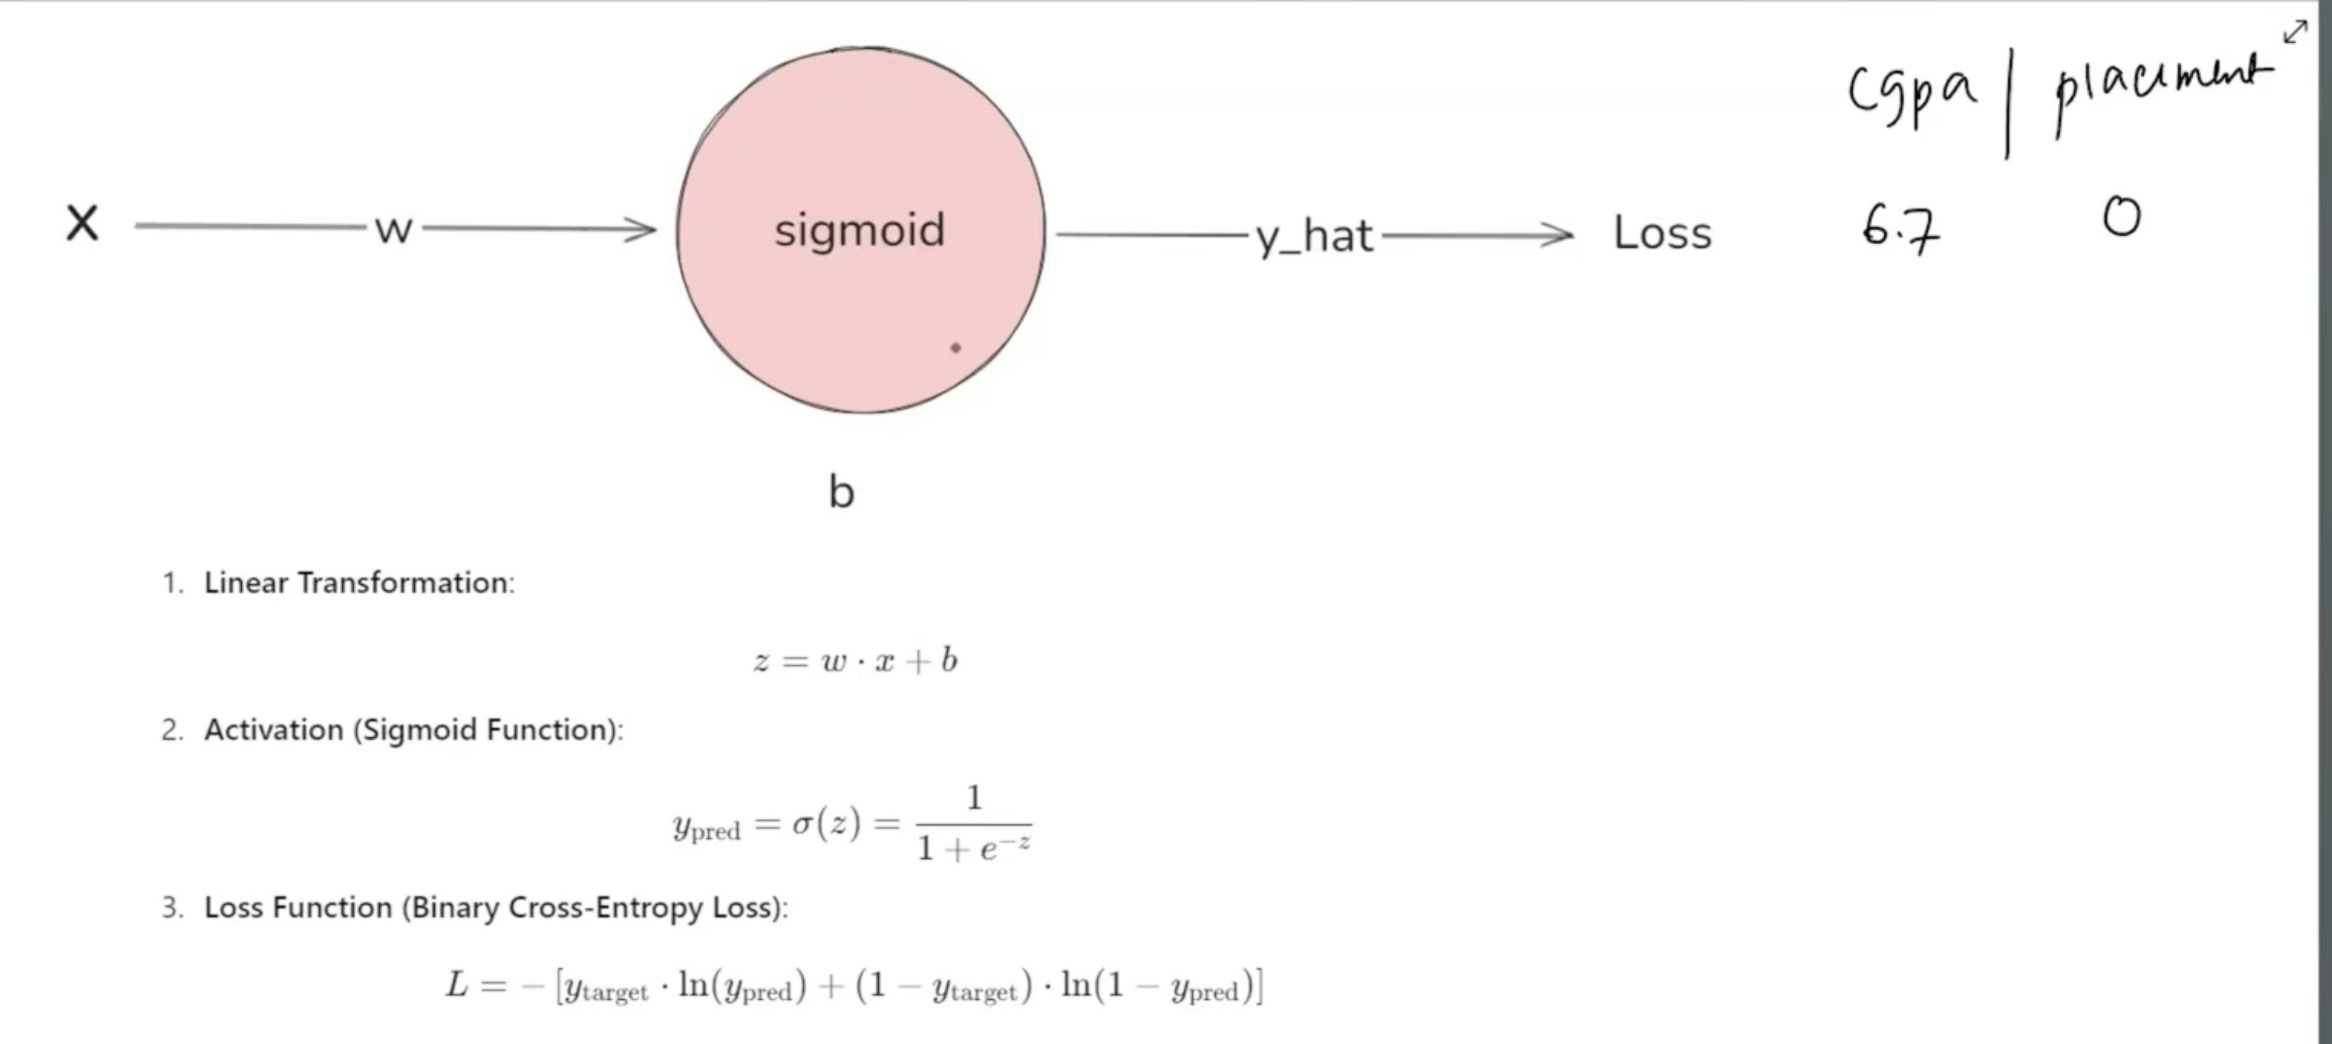

Suppose we have only one point to train the neural network


cgpa is 6.7 and he isn't placed in any company

In [25]:
## 1.we need to cal derivative of loss wrt w that is dL/dw
## 2.we need to cal derivative of loss wrt b that is dL/db

## dL/dw=dL/dy_hat * dy_hat/dz * dz/dw

## dL/db=dL/dy_hat * dy_hat/dz * dz/db

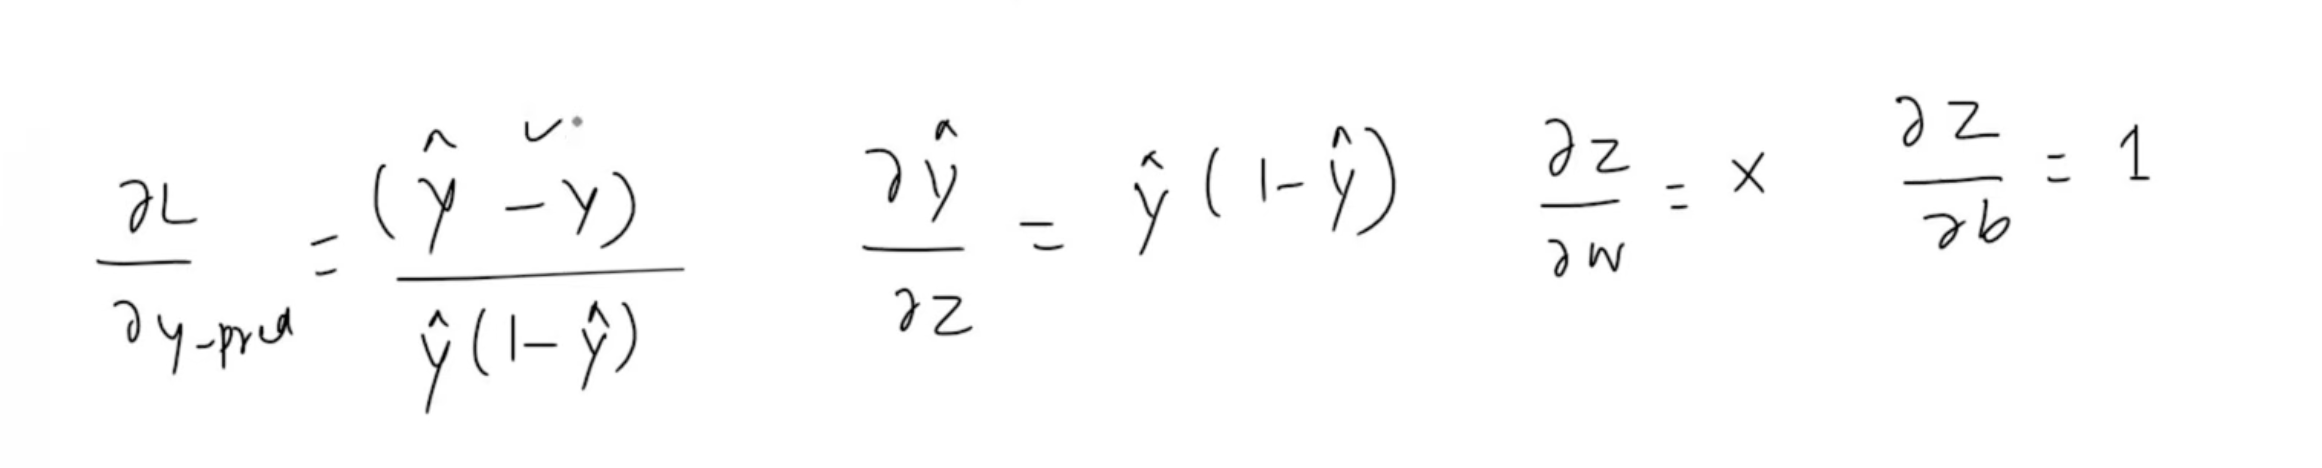

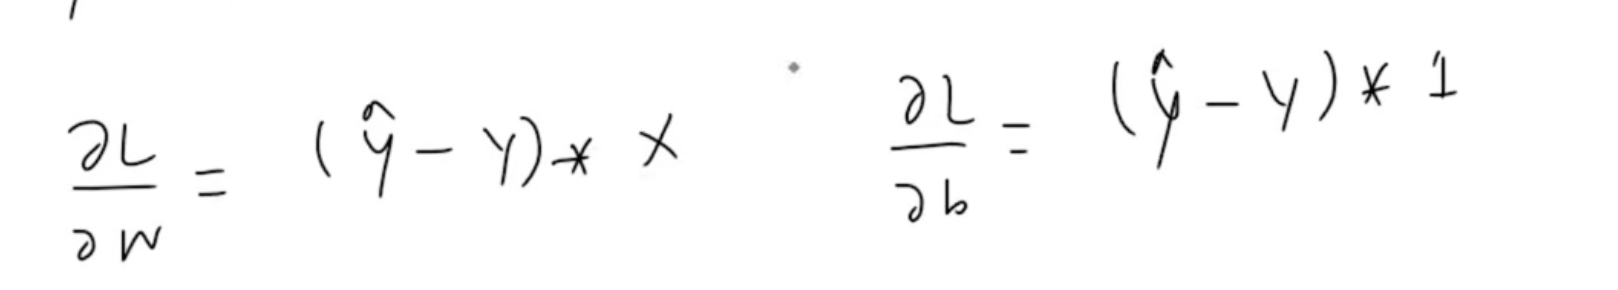

In [26]:
import torch
## cgpa is 6.7 and is not placed
x=torch.tensor(6.7) ## Input feature
y=torch.tensor(0.0) ## True Label (Binary)


w=torch.tensor(1.0) ## Weight
b=torch.tensor(0.0) ## Bias

In [29]:
## Binary Cross Entropy loss for scalar

def binary_cross_entropy_loss(prediction,target):
  return -(target * torch.log(prediction) +(1-target)*(torch.log(1-prediction)))


In [28]:
## Forward Pass
z=w*x+b ## weighted sum(linear part)
y_pred=torch.sigmoid(z) ##Predicted probability

In [31]:
## compute loss value

loss=binary_cross_entropy_loss(y_pred,y)
loss

tensor(6.7012)

In [32]:
## Derivates

## 1. dL/dy_pred: loss wrt prediction
dloss_dy_pred=(y_pred-y)/((y_pred)*(1-y_pred))

## 2. dy_pred/dz: prediction wrt z

dy_pred_dz=(1-y_pred)*y_pred

## 3. dz/dw and dz/db

dz_dw=x
dz_db=1


dL_dw=dloss_dy_pred * dy_pred_dz * dz_dw
dL_db=dloss_dy_pred * dy_pred_dz * dz_db

In [36]:
print(f"Manual gradient of loss wrt weight(w):{dL_dw:.4f}")
print(f"Manual gradient of loss wrt bias(b):{dL_db:.4f}")

Manual gradient of loss wrt weight(w):6.6918
Manual gradient of loss wrt bias(b):0.9988


## Using Autograd

In [38]:
x=torch.tensor(6.7)
y=torch.tensor(0.0)

## we didn't write requires_grad=True for x and y bcz we do not want to cal derivative wrt x and y




w=torch.tensor(1.0,requires_grad=True) ## Weight
b=torch.tensor(0.0,requires_grad=True) ## Bias

In [39]:
## fwd propagation

z=w*x+b
y_pred=torch.sigmoid(z)


In [40]:
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [41]:
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [43]:
loss=binary_cross_entropy_loss(y_pred,y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

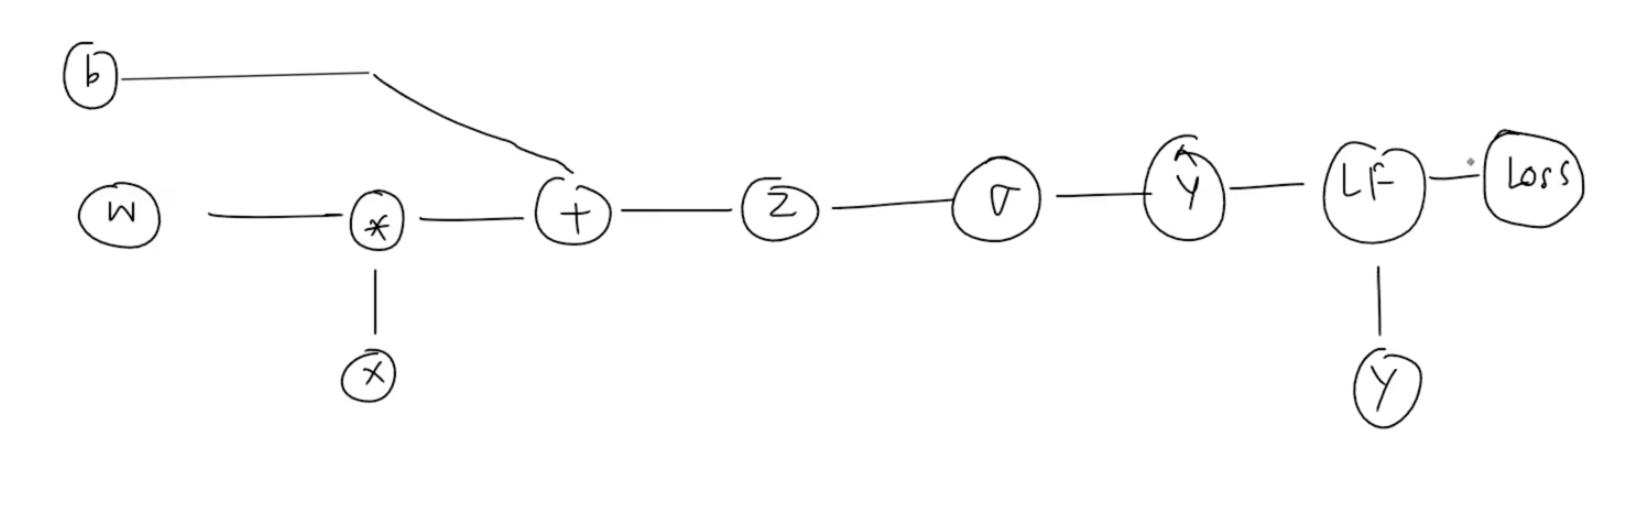

LF is loss function

above graph is computation graph

In [44]:
loss.backward()

In [47]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


## Working with vectors now

In [54]:
x=torch.tensor([1.0,2.0,3.0],requires_grad=True)
y=(x**2).mean()
y.backward()
x.grad

tensor([0.6667, 1.3333, 2.0000])

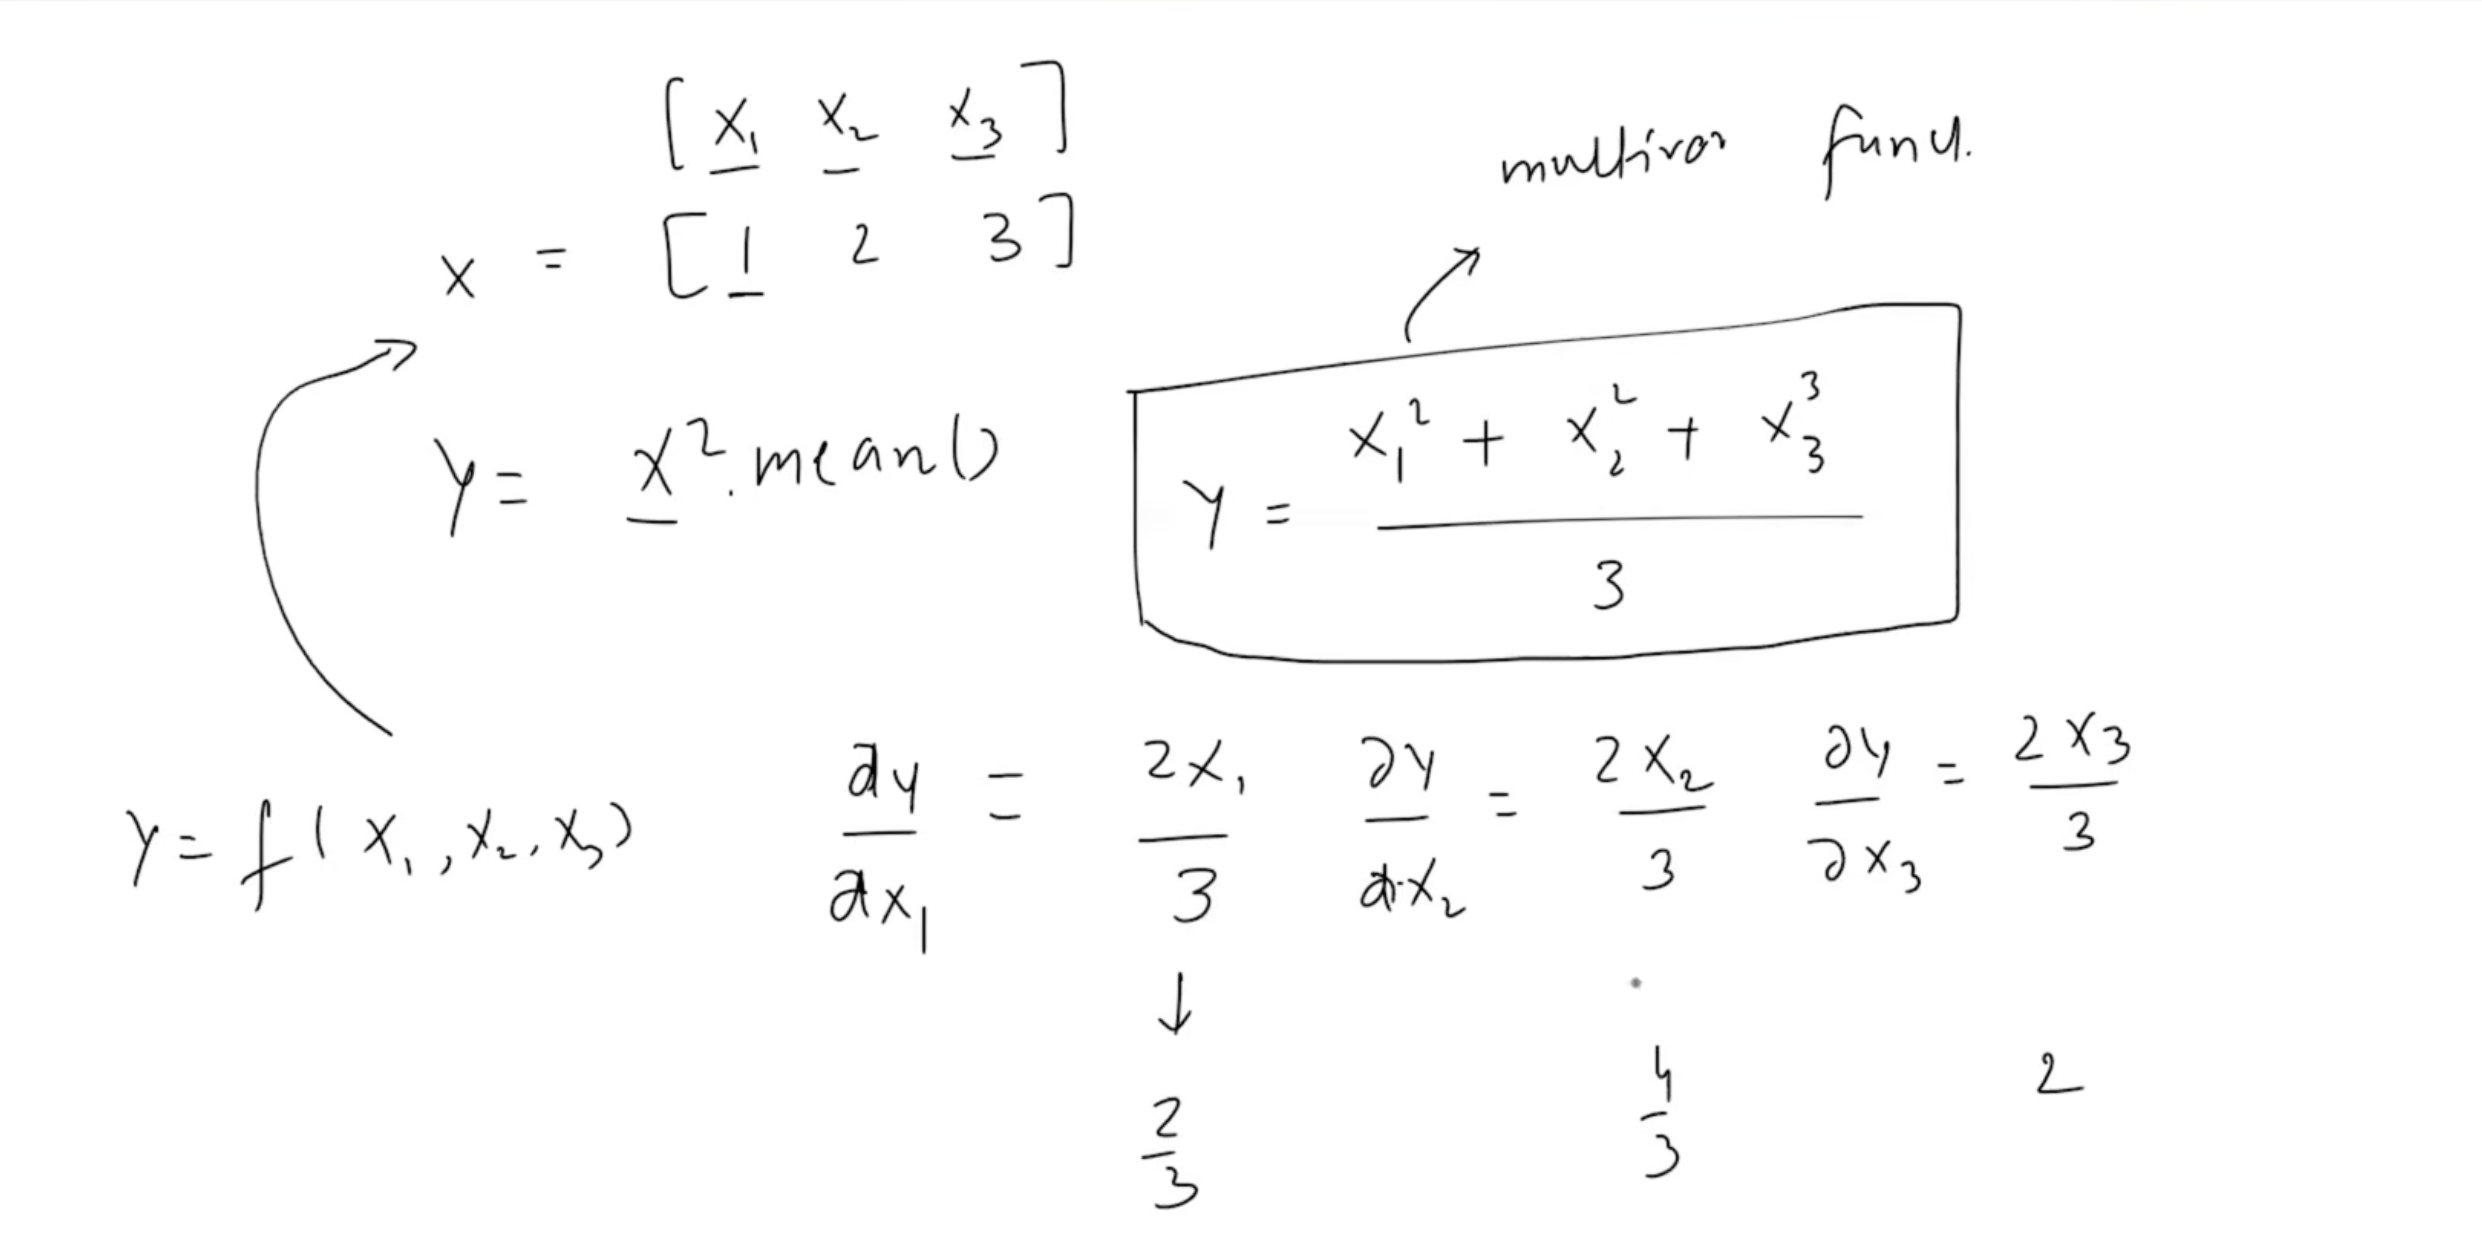

In [69]:
## clearing grad

x=torch.tensor(2.0,requires_grad=True)
y=x**2



In [70]:
y.backward()

In [71]:
x.grad

tensor(4.)

In [72]:
## second time calling it
y.backward()
## pichle pass ka gradient next passs ke gradient mein add hojata hai
## whenever we are doing multiple passes we need to ensure that we clear our gradient before that

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [74]:
x.grad.zero_() ## clearing the gradients

tensor(0.)

## Disabling gradient tracking

In [ ]:
## options:
## 1. requires_grad_(False)
## 2. detach()
## 3. torch.no_grad()

In [77]:
## there will be requirements where you do not need to cal gradients.In that case, disable gradient tracking
## this scenario can arise when you trained your model and just need to use your model for predictions..disable gradient tracking in this case

In [78]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [79]:
y=x**2

In [80]:
y.backward()
x.grad

tensor(4.)

In [81]:
## now training is completed and I only need forward pass no backward pass
## gradient tracking consumes a lot of memory just disable it

In [82]:
x.requires_grad_(False)

tensor(2.)

In [83]:
x

tensor(2.)

In [85]:
y=x**2
y

tensor(4.)

In [86]:
y.backward()

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [87]:
## detach

x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [89]:
z=x.detach()
z
## z will have exactly all the values present in x

tensor(2.)

In [90]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [91]:
y=z**2
y

tensor(4.)

In [93]:
## no_grad()

x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [94]:
with torch.no_grad():
  y=x**2

In [95]:
y

tensor(4.)

In [96]:
y.backward()


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn